## Task 3: Customer Segmentation and Profiling

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.cluster import KMeans

In [3]:
df = pd.read_csv("../data/Amazon_cleaned.csv")
df.head()

,Timestamp,age,Gender,Purchase_Frequency,Purchase_Categories,Personalized_Recommendation_Frequency,Browsing_Frequency,Product_Search_Method,Search_Result_Exploration,Customer_Reviews_Importance,...,Review_Reliability,Review_Helpfulness,Personalized_Recommendation_Score,Recommendation_Helpfulness,Rating_Accuracy,Shopping_Satisfaction,Service_Appreciation,Improvement_Areas,transaction,Purchase_Categories_List
0,2023-06-08 19:50:55+05:30,65,Prefer Not To Say,Less Than Once A Month,Clothing and Fashion,Yes,Multiple Times A Day,Keyword,Multiple Pages,2,...,Moderately,No,2,Sometimes,4,4,Competitive Prices,better app interface and lower shipping charges,778242,['Clothing and Fashion']
1,2023-06-09 09:37:44+05:30,20,Male,Once A Week,Groceries and Gourmet Food;Beauty and Personal...,No,Rarely,Filter,First Page,3,...,Heavily,Yes,1,Sometimes,4,5,Quick Delivery,Scrolling option would be much better than goi...,193482,"['Groceries and Gourmet Food', 'Beauty and Per..."
2,2023-06-11 23:26:54+05:30,42,Male,Once A Week,Groceries and Gourmet Food;Beauty and Personal...,Sometimes,Few Times A Week,Keyword,Multiple Pages,2,...,Heavily,Sometimes,5,No,5,3,All The Above,Nil,925975,"['Groceries and Gourmet Food', 'Beauty and Per..."
3,2023-06-08 17:17:10+05:30,65,Others,Once A Month,Beauty and Personal Care;Clothing and Fashion;...,No,Few Times A Month,Filter,Multiple Pages,2,...,Occasionally,No,3,Yes,1,2,Quick Delivery,Quality of product is very poor according to t...,566872,"['Beauty and Personal Care', 'Clothing and Fas..."
4,2023-06-11 22:59:30+05:30,45,Female,Once A Week,Beauty and Personal Care;Clothing and Fashion;...,Sometimes,Few Times A Month,Not Specified,First Page,5,...,Rarely,No,2,Yes,1,2,Quick Delivery,Irrelevant product suggestions,683642,"['Beauty and Personal Care', 'Clothing and Fas..."


In [4]:
# Remove unwanted spaces from column names
df.columns = df.columns.str.strip()

# Copy dataframe
customer_df = df.copy()

In [5]:
customer_df["Purchase_Frequency"].unique()

array(['Less Than Once A Month', 'Once A Week', 'Once A Month',
       'Few Times A Month', 'Multiple Times A Week'], dtype=object)

In [21]:
# Frequency mapping for Purchase_Frequency 

frequency_mapping = {
    "Multiple Times A Week": 5,
    "Once A Week": 4,
    "Few Times A Month": 3,
    "Once A Month": 2,
    "Less Than Once A Month": 1
}

customer_df["Purchase_Score"] = customer_df["Purchase_Frequency"].map(frequency_mapping)

In [7]:
# Shopping satisfaction score 

customer_df["Shopping_Satisfaction"] = pd.to_numeric(
    customer_df["Shopping_Satisfaction"],
    errors="coerce"
)

In [8]:
# Customer profile creation 

conditions = [
    (customer_df["Purchase_Score"] >= 4) &
    (customer_df["Shopping_Satisfaction"] >= 4),

    (customer_df["Purchase_Score"] == 3) &
    (customer_df["Shopping_Satisfaction"] >= 3),

    (customer_df["Shopping_Satisfaction"] <= 2)
]

choices = [
    "Frequent Buyer",
    "Occasional Shopper",
    "At-Risk Customer"
]

customer_df["Customer_Profile"] = np.select(
    conditions,
    choices,
    default="Regular Customer"
)

## Distribution of Customer Profile 

**Purpose:**
- To understand how customers are distributed across business segments.

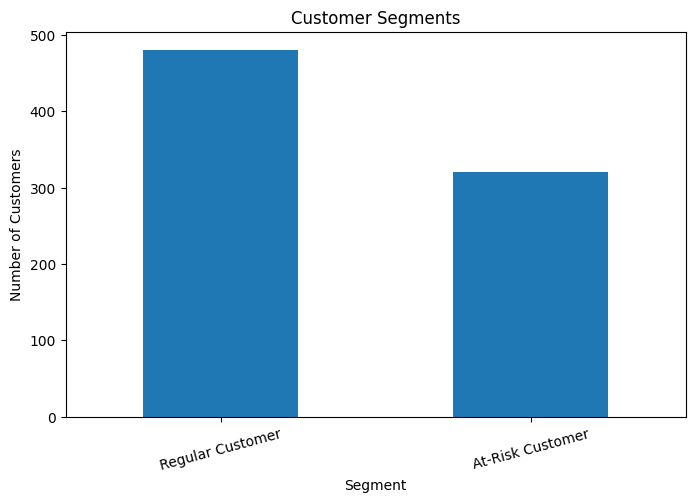

In [9]:
# Distribution of Customer profiles

profile_counts = customer_df["Customer_Profile"].value_counts()

plt.figure(figsize=(8,5))
profile_counts.plot(kind="bar")

plt.title("Customer Segments")
plt.xlabel("Segment")
plt.ylabel("Number of Customers")

plt.xticks(rotation=15)

plt.show()

## Demographic Analysis

**Purpose:**
- To check whether age and gender differ across customer profiles.

In [13]:
customer_df.groupby("Customer_Profile")["age"].mean().sort_values()

Customer_Profile
Regular Customer    34.756250
At-Risk Customer    35.790625
Name: age, dtype: float64

In [14]:
# Gender distribution 

pd.crosstab(
    customer_df["Customer_Profile"],
    customer_df["Gender"]
)

Gender,Female,Male,Others,Prefer Not To Say
Customer_Profile,,,,
At-Risk Customer,72,93,77,78
Regular Customer,125,116,125,114


## Behavioral Analysis

**Purpose:**
- To compare purchasing behavior across segments.

In [12]:
customer_df.groupby("Customer_Profile")[[
    "Purchase_Score",
    "Shopping_Satisfaction"
]].mean()

,Purchase_Score,Shopping_Satisfaction
Customer_Profile,,
At-Risk Customer,NaN,1.525000
Regular Customer,NaN,4.004167


# K-Means Clustering

**Purpose:**
- To prepare numerical features for clustering.

In [15]:
cluster_data = customer_df[[
    "Purchase_Score",
    "Shopping_Satisfaction"
]].dropna()

In [25]:
# Standardize the features for clustering

scaler = StandardScaler()

scaled_data = scaler.fit_transform(cluster_data)

In [26]:
# Applying K-Means

kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

cluster_labels = kmeans.fit_predict(scaled_data)

cluster_data["Cluster"] = cluster_labels

## Cluster Visualization

**Purpose:**
- Visualize how customers naturally group based on purchase frequency and satisfaction.

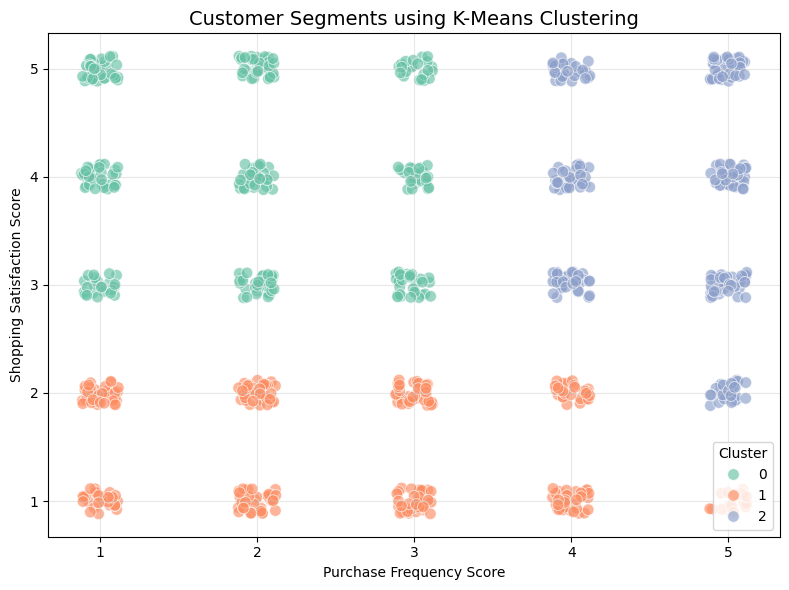

In [29]:
# Create a copy for visualization
plot_df = cluster_data.copy()

# Add slight random noise (jitter) to reduce overlapping points
np.random.seed(42)

plot_df["Purchase_Jitter"] = (
    plot_df["Purchase_Score"] +
    np.random.uniform(-0.12, 0.12, len(plot_df))
)

plot_df["Satisfaction_Jitter"] = (
    plot_df["Shopping_Satisfaction"] +
    np.random.uniform(-0.12, 0.12, len(plot_df))
)

# Plot clusters
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=plot_df,
    x="Purchase_Jitter",
    y="Satisfaction_Jitter",
    hue="Cluster",
    palette="Set2",
    s=70,
    alpha=0.65
)

plt.title("Customer Segments using K-Means Clustering", fontsize=14)
plt.xlabel("Purchase Frequency Score")
plt.ylabel("Shopping Satisfaction Score")
plt.xticks([1, 2, 3, 4, 5])
plt.yticks([1, 2, 3, 4, 5])
plt.grid(alpha=0.3)

plt.legend(title="Cluster")
plt.tight_layout()

plt.show()

**Insights:**
- Cluster 2 represents the most valuable customer segment, with the highest average Purchase Frequency Score (4.59) and high average Shopping Satisfaction Score (3.74). These customers purchase frequently and are generally satisfied, making them ideal candidates for loyalty rewards, exclusive offers, and premium membership campaigns.
- Cluster 1 has the lowest average Shopping Satisfaction Score (1.48) while maintaining a moderate Purchase Frequency Score (2.66). This indicates that these customers continue to shop despite having poor experiences, making them the segment most at risk of churn. Addressing their concerns through improved service quality, pricing strategies, or customer support could significantly improve retention.
- Cluster 0 consists of customers with a low average Purchase Frequency Score (1.96) but the highest average Shopping Satisfaction Score (4.03). These customers appear satisfied with their shopping experience but purchase infrequently. Personalized recommendations, targeted promotions, and reminder campaigns could encourage them to shop more often.

In [28]:
# Chart Summary
cluster_data.groupby("Cluster").mean()

,Purchase_Score,Shopping_Satisfaction
Cluster,,
0,1.963100,4.025830
1,2.660959,1.479452
2,4.590717,3.742616


| Cluster       | Interpretation                                                                                                                          |
| ------------- | --------------------------------------------------------------------------------------------------------------------------------------- |
| **Cluster 0** | **Satisfied Occasional Buyers** – Happy customers who purchase infrequently. Increase purchase frequency through personalized offers.   |
| **Cluster 1** | **At-Risk Customers** – Low satisfaction despite moderate purchasing activity. Prioritize service improvements and retention campaigns. |
| **Cluster 2** | **Loyal Customers** – Frequent purchasers with high satisfaction. Focus on loyalty programs, cross-selling, and premium benefits.       |
